In [ ]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import concurrent.futures


gleap_target = md.load("../../2_md-preparation/gleap.target.gro")
atom_indices_ligand = gleap_target.topology.select("resid 33")
atom_indices_rna     = gleap_target.topology.select("resid  0 to  32")
# atom_indices_rna_docking_surface = gleap_target.topology.select("resid 7 to 16") ## How to select
atom_index_ligand_min = min(atom_indices_ligand)

pickle_dir = "./pickle-cache/interactions_hbond"


def calculate_interactions(xtc):
    _interactions = np.zeros((len(atom_indices_ligand), len(atom_indices_rna), xtc.n_frames))
    for timestep in range(xtc.n_frames):
        hbonds = md.baker_hubbard(xtc[timestep], distance_cutoff=0.3, angle_cutoff=120)
        for pair in hbonds:
            atom_index_donor    = pair[0]
            atom_index_hydrogen = pair[1]
            atom_index_acceptor = pair[2]
            protein_atom_index = 0
            rna_atom_index     = 0
            if atom_index_hydrogen in atom_indices_ligand and atom_index_acceptor in atom_indices_rna:
                atom_index_ligand = atom_index_hydrogen
                atom_index_rna     = atom_index_acceptor
            elif atom_index_hydrogen in atom_indices_rna   and atom_index_acceptor in atom_indices_ligand:
                atom_index_ligand = atom_index_acceptor
                atom_index_rna     = atom_index_hydrogen
            else:
                continue
            _interactions[atom_index_ligand-atom_index_ligand_min, atom_index_rna, timestep] += 1
    return _interactions
    

if True:
    def worker(trial):
        print(trial, "start")
        if trial == "cmd":
            interactions = np.zeros((len(atom_indices_ligand), len(atom_indices_rna), 801))
            xtc = md.load(f"../../6_cmd-1/cmd.skip10.whole.target.xtc", top=gleap_target)[2001::10]
            interactions = calculate_interactions(xtc)
            nonzero_indices = interactions.nonzero()
            nonzero_values  = interactions[nonzero_indices]
            pickle.dump([nonzero_indices, nonzero_values], open(f"{pickle_dir}/cmd_interactions.pickle", "wb"))
        else:
            interactions = np.zeros((len(atom_indices_ligand), len(atom_indices_rna), 120))
            if trial == 5:
                trial = 11
            xtc = md.load(f"../../pacs2/trial{trial+1:03}/prd.target.trjcat-all.pbc.skip10.xtc", top=gleap_target)[::10]
            coms_ligand             = md.compute_center_of_mass(xtc.atom_slice(atom_indices_ligand))
            coms_rna_docking_surface = md.compute_center_of_mass(xtc.atom_slice(atom_indices_rna))
            com_distances = np.linalg.norm(coms_rna_docking_surface-coms_ligand, axis=1)
            com_distances_binned = (com_distances*10).astype(int)

            _interactions = calculate_interactions(xtc)
            for timestep, com_distance_binned in enumerate(com_distances_binned):
                interactions[:, :, com_distance_binned] += _interactions[:, :, timestep]
            nonzero_indices = interactions.nonzero()
            nonzero_values  = interactions[nonzero_indices]
            pickle.dump([nonzero_indices, nonzero_values], open(f"{pickle_dir}/pacs_interactions_{trial}.pickle", "wb"))
            pickle.dump(np.bincount(com_distances_binned, minlength=120), open(f"{pickle_dir}/pacs_com_distances_bincount_{trial}.pickle", "wb"))
        print(trial, "completed")
    if not os.path.exists(pickle_dir):
        os.mkdir(pickle_dir)
    trials = ["cmd"]
    trials.extend(range(10))
    for _ in concurrent.futures.ProcessPoolExecutor(max_workers=12).map(worker, trials):
        pass


cmd_interactions = np.zeros((len(atom_indices_ligand), len(atom_indices_rna), 801))
nonzero_indices, nonzero_values = pickle.load(open(f"{pickle_dir}/cmd_interactions.pickle", "rb"))
cmd_interactions[nonzero_indices] = nonzero_values

pacs_interactions = np.zeros((10, len(atom_indices_ligand), len(atom_indices_rna), 120))
pacs_com_distances_bincount = np.zeros((10, 120))
for trial in range(len(pacs_interactions)):
    nonzero_indices, nonzero_values = pickle.load(open(f"{pickle_dir}/pacs_interactions_{trial}.pickle", "rb"))
    pacs_interactions[trial][nonzero_indices] = nonzero_values
    pacs_com_distances_bincount[trial] = pickle.load(open(f"{pickle_dir}/pacs_com_distances_bincount_{trial}.pickle", "rb"))

pacs_interactions /= pacs_com_distances_bincount[:, np.newaxis, np.newaxis, :]
del pacs_com_distances_bincount

cmd1052436789          start startstartstartstartstartstartstartstartstart
start









cmd completed


Process ForkProcess-1:
Process ForkProcess-7:
Process ForkProcess-12:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/gs/bs/tga-Kitao-Lab/yilan/softwares/miniconda3/envs/pacsmd2/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/gs/bs/tga-Kitao-Lab/yilan/softwares/miniconda3/envs/pacsmd2/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/gs/bs/tga-Kitao-Lab/yilan/softwares/miniconda3/envs/pacsmd2/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/gs/bs/tga-Kitao-Lab/yilan/softwares/miniconda3/envs/pacsmd2/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/gs/bs/tga-Kitao-Lab/yilan/softwares/miniconda3/envs/pacsmd2/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/gs/bs/tg

KeyboardInterrupt: 

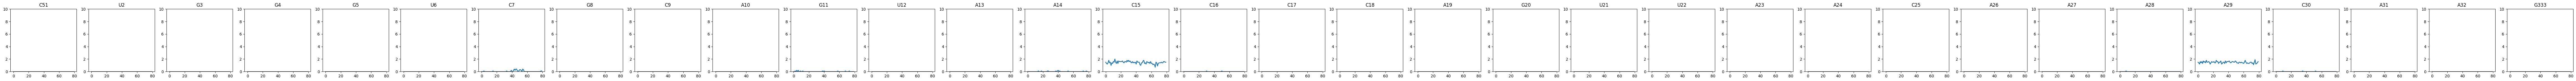

In [4]:
YMAX = 10

fig, ax = plt.subplots(1,33)
fig.set_size_inches(92, 3)

for residue_index_rna in range(0, 33):
    atom_indices_rna_residue = gleap_target.topology.select(f"resid {residue_index_rna}")
    atom_index_rna_residue_min = min(atom_indices_rna_residue)
    atom_index_rna_residue_max = max(atom_indices_rna_residue)
    ax[residue_index_rna].plot(cmd_interactions[:, atom_index_rna_residue_min:atom_index_rna_residue_max+1, :-1].sum(axis=(0, 1)).reshape(-1, 10).mean(axis=1), linewidth=2)

    ax[residue_index_rna].set_title(gleap_target.topology.residue(residue_index_rna))
    ax[residue_index_rna].set_ylim(0, YMAX)

fig.tight_layout()
fig.savefig("./figures/hbond1.png", dpi=300, bbox_inches="tight")

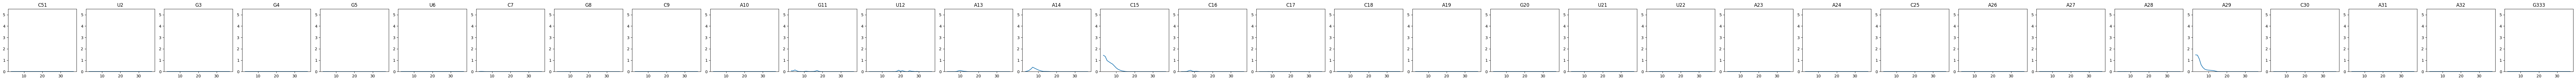

In [8]:
fig, ax = plt.subplots(1, 33)
fig.set_size_inches(92, 3)

pacs_interactions_trial_mean = pacs_interactions.mean(axis=0)

for residue_index_rna in range(0, 33):
    atom_idices_rna_residue = gleap_target.topology.select(f"resid {residue_index_rna}")

    pacs_interactions_trial_mean_rna_sum = pacs_interactions_trial_mean[:, atom_idices_rna_residue].sum(axis=1)
    ax[residue_index_rna].plot(pacs_interactions_trial_mean_rna_sum.sum(axis=0))
   
    # ax[residue_index_rna].plot(pacs_interactions_trial_mean_rna_sum[atom_indices_ligand_rgion["rrm"]-atom_index_ligand_min].sum(axis=0))
    # ax[residue_index_rna].plot(pacs_interactions_trial_mean_rna_sum[atom_indices_ligand_rgion["rgg"]-atom_index_ligand_min].sum(axis=0))

    ax[residue_index_rna].set_title(gleap_target.topology.residue(residue_index_rna))
    ax[residue_index_rna].set_ylim(0, 5.5)


fig.tight_layout()
fig.savefig("./figures/hbond3.png", dpi=300, bbox_inches="tight")

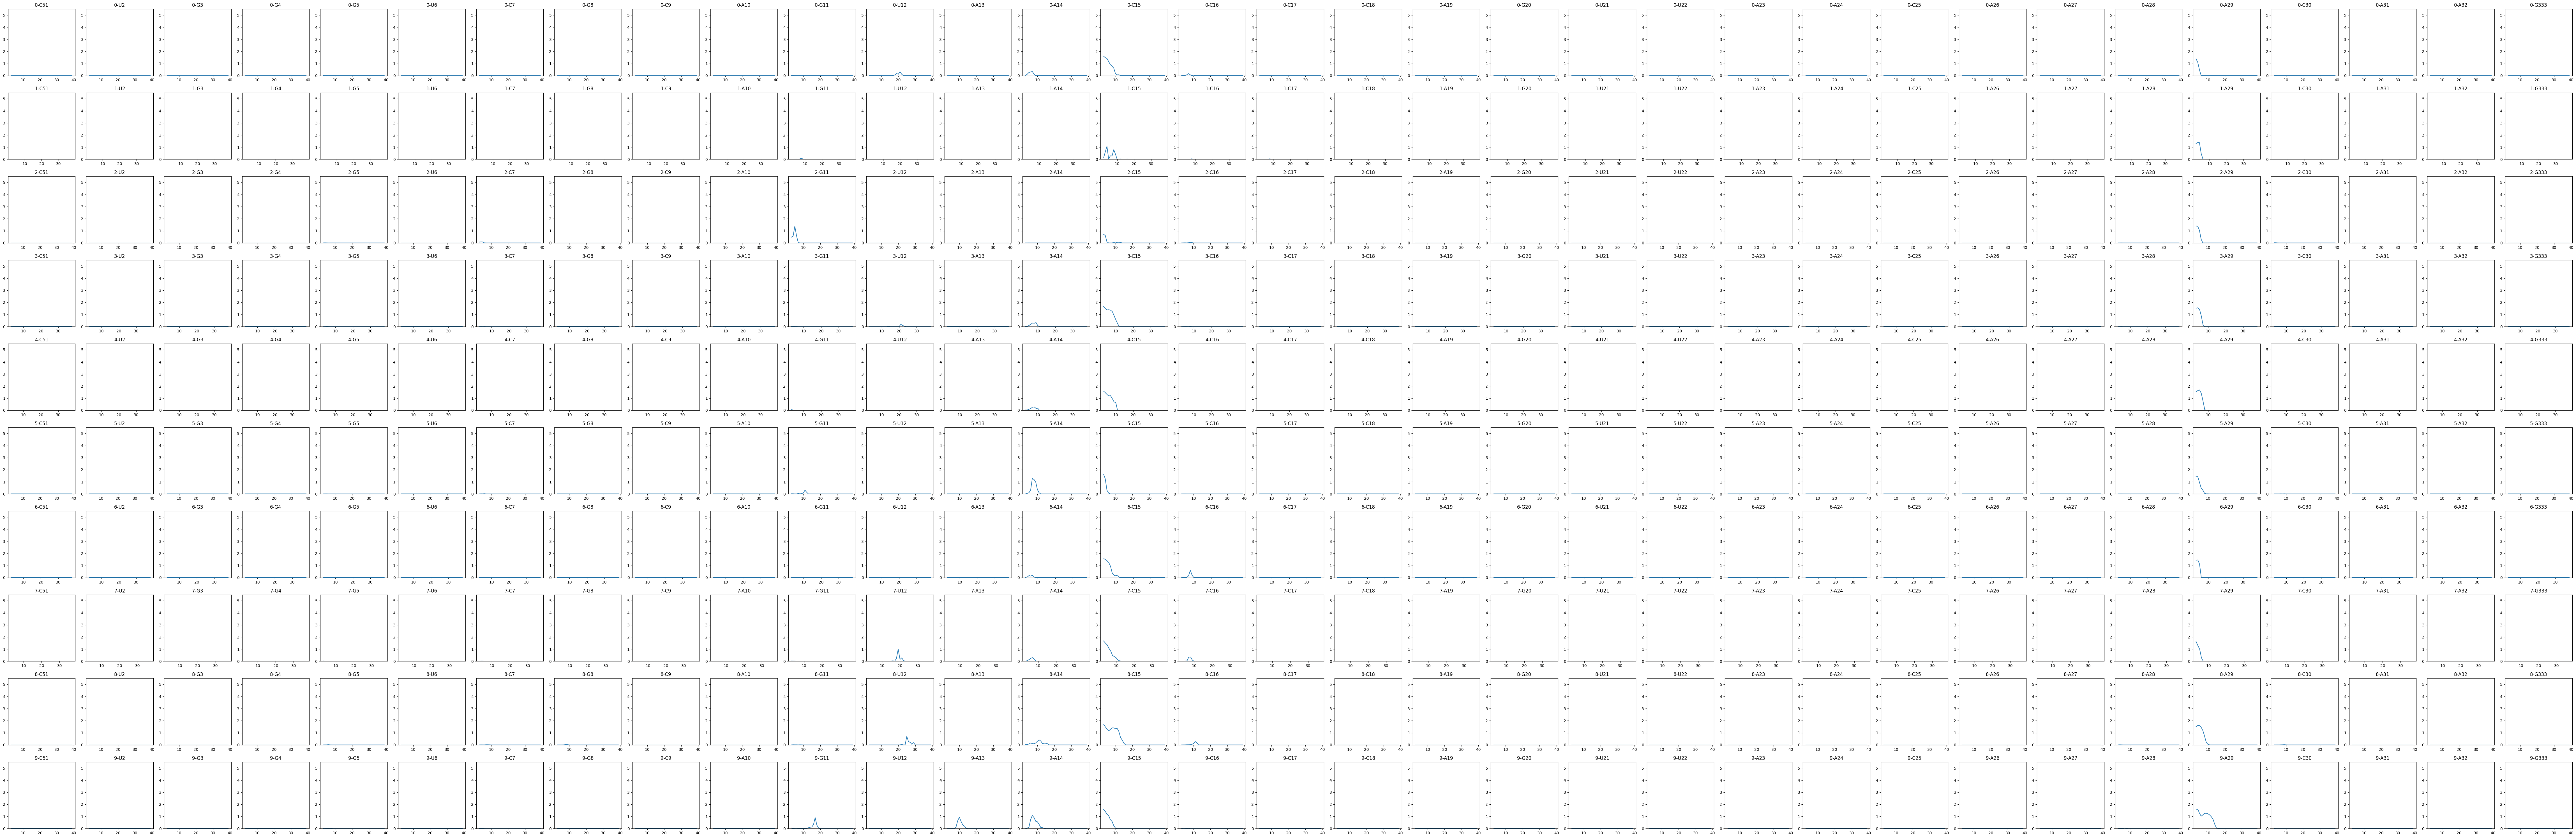

In [7]:
fig, ax = plt.subplots(len(pacs_interactions), 33)
fig.set_size_inches(92, 3*len(pacs_interactions))

for trial in range(len(pacs_interactions)):
    for residue_index_rna in range(0, 33):
        atom_idices_rna_residue = gleap_target.topology.select(f"resid {residue_index_rna}")

        pacs_interactions_rna_sum = pacs_interactions[trial, :, atom_idices_rna_residue].sum(axis=0)
        ax[trial, residue_index_rna].plot(pacs_interactions_rna_sum[atom_indices_ligand-atom_index_ligand_min].sum(axis=0))

        # ax[trial, residue_index_rna].plot(pacs_interactions_rna_sum[atom_indices_ligand_rgion["rrm"]-atom_index_ligand_min].sum(axis=0))
        # ax[trial, residue_index_rna].plot(pacs_interactions_rna_sum[atom_indices_ligand_rgion["rgg"]-atom_index_ligand_min].sum(axis=0))

        ax[trial, residue_index_rna].set_title(f"{trial}-{gleap_target.topology.residue(residue_index_rna)}")
        ax[trial, residue_index_rna].set_ylim(0, 5.5)

fig.tight_layout()
fig.savefig("./figures/hbond2.png", dpi=300, bbox_inches="tight")